# Simple End-to-End Example

In [7]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

 54% (57 of 104) |############           | Elapsed Time: 0:00:00 ETA:   0:00:00

PAGE 1/1


100% (104 of 104) |######################| Elapsed Time: 0:00:00 Time:  0:00:000:00
  5% (6 of 104) |#                       | Elapsed Time: 0:00:00 ETA:   0:00:01

Building [3423 x 5447] spatial index...


100% (104 of 104) |######################| Elapsed Time: 0:00:07 Time:  0:00:070000


Number of edges= 104
Number of nodes= 76


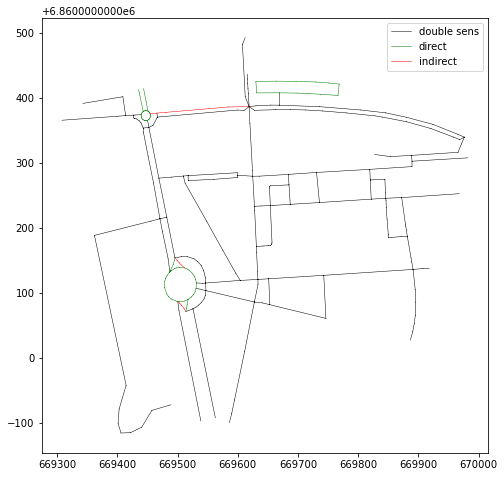

In [12]:
xmin = 2.58183
xmax = 2.58988
ymin = 48.83999
ymax = 48.84301

bbox = tkl.Bbox(tkl.GeoCoords(xmin, ymin), tkl.GeoCoords(xmax, ymax))
tolerance = 0.0001

spatialIndex = True

network = tkl.NetworkReader.requestFromIgnGeoportail(bbox, tolerance=tolerance, spatialIndex=spatialIndex)
network.toENUCoords(2154)

plt.figure(figsize=(8, 8))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)
print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
plt.legend()

In [13]:
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))
simu = tkl.generateTracksOnNetwork(network, N=1000, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

100% (1000 of 1000) |####################| Elapsed Time: 0:00:07 Time:  0:00:070000


------------------------------------------------------------
942 (94.2 %) tracks generated on network
------------------------------------------------------------


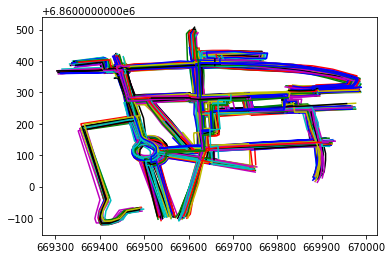

In [15]:
simu.plot()